examples/example.jl

Reproduces the Arellano-Bond (1991) employment equation (Table 4, column
a2) on the EmplUK dataset, the same panel used in the original paper, and
checks the package's estimates and diagnostics against the published
numbers.

In [1]:
using DynamicPanelModels
using DataFrames
using CSV
using Downloads
using Plots
using Statistics
using LinearAlgebra

# Load the EmplUK dataset (Arellano & Bond, 1991): employment, wages,
# capital, and output for UK firms, 1976-1984.
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/plm/EmplUK.csv"
df = CSV.read(Downloads.download(url), DataFrame)

first(df, 5)
show(describe(df); allrows=true, allcols=true)

8×7 DataFrame
 Row │ variable  mean        min        median    max        nmissing  eltype   
     │ Symbol    Float64     Real       Float64   Real       Int64     DataType 
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ rownames   516.0         1        516.0    1031              0  Int64
   2 │ firm        73.2037      1         74.0     140              0  Int64
   3 │ year      1979.65     1976       1980.0    1984              0  Int64
   4 │ sector       5.12318     1          5.0       9              0  Int64
   5 │ emp          7.89168     0.104      2.287   108.562          0  Float64
   6 │ wage        23.9188      8.0171    24.006    45.2318         0  Float64
   7 │ capital      2.50743     0.0119     0.518    47.1079         0  Float64
   8 │ output     103.801      86.9      100.55    128.365          0  Float64

Panel balance

In [2]:
obs_per_firm = combine(groupby(df, :firm), nrow => :count)
println("Min years per firm: ", minimum(obs_per_firm.count))
println("Max years per firm: ", maximum(obs_per_firm.count))
println("Average years per firm: ", round(mean(obs_per_firm.count); digits=2))

# The paper's employment equation (16) is specified in logs, with two lags
# of employment and one or two lags of each covariate.
df.n = log.(df.emp)
df.w = log.(df.wage)
df.k = log.(df.capital)
df.ys = log.(df.output)

Min years per firm: 7


Max years per firm: 9
Average years per firm: 7.36


1031-element Vector{Float64}:
 4.561293520290072
 4.578383638395187
 4.601245484412533
 4.610656110748251
 4.600741373259052
 4.591224363478164
 4.60547114069668
 4.561293520290072
 4.578383638395187
 4.601245484412533
 4.610656110748251
 4.600741373259052
 4.591224363478164
 ⋮
 4.51534173203327
 4.53222303520508
 4.571942159167752
 4.651733109793325
 4.677296410061319
 4.690602650484494
 4.7145544953190734
 4.605170185988092
 4.599116901774991
 4.598076062089614
 4.673696682072273
 4.731424791903161

Correlation matrix


══════════════════════════════════════════════════════════════════════════════
  Dynamic Panel Data Estimation
══════════════════════════════════════════════════════════════════════════════
  Method:                2-step DifferenceGMM
  Formula:               n ~ lag(n) + lag(n,2) + w + lag(w) + k + lag(k) + lag(k,2) + ys + lag(ys) + lag(ys,2)
  Std. Errors:           Windmeijer (2005) corrected
──────────────────────────────────────────────────────────────────────────────
  Observations:                   611    Groups:                  140
  Instruments:                     35
──────────────────────────────────────────────────────────────────────────────
  Variable         Estimate   Std. Error    z-value   Pr(>|z|)
──────────────────────────────────────────────────────────────────────────────
  L.n               0.61134      0.21691     2.8184     0.0048 ** 
  L2.n             -0.05842      0.04910    -1.1899     0.2341    
  w                -0.54303      0.16769    -3.2383     0

      GMM DIAGNOSTIC REPORT
Sargan J-test (validity):   stat =   32.462, p-val = 0.1451
AR(1) test (serial corr):   stat =   -1.988, p-val = 0.0468


AR(2) test (serial corr):   stat =   -0.356, p-val = 0.7218
Jarque-Bera (normality):    stat = 1099.567, p-val = 0.0000
------------------------------------------------------------
OK: Instruments: 35, Groups: 140 (Ratio: 0.25)


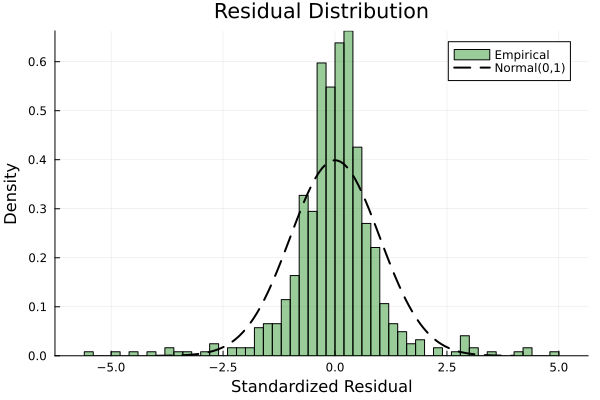

In [3]:
vars_to_check = [:n, :w, :k, :ys]
cor_matrix = cor(Matrix(df[:, vars_to_check]))
DataFrame(cor_matrix, vars_to_check)

# Difference GMM (Arellano-Bond), two-step with Windmeijer-corrected SEs.
# `w`, `k`, and `ys` (and their lags) are treated as strictly exogenous, as
# in the paper's columns (a1)/(a2); only the lagged dependent variable is
# instrumented via its own further lags.
model = fit(
    DifferenceGMM(; robust=true, steps=2),
    df;
    formula="n ~ lag(n) + lag(n,2) + w + lag(w) + k + lag(k) + lag(k,2) + ys + lag(ys) + lag(ys,2)",
    id_col=:firm,
    time_col=:year,
    exog=["w", "L.w", "k", "L.k", "L2.k", "ys", "L.ys", "L2.ys"],
)
display(model)

# Diagnostics. Compare against Table 4, column (a2): n_{t-1}=0.629,
# n_{t-2}=-0.065, w_t=-0.526, k_t=0.278, ys_t=0.592, Sargan chi2(25)=31.4 —
# the package's estimates and Sargan statistic land close to the published
# values, and neither AR(1) nor AR(2) points to misspecification.
diagnose(model)

# Visualization
plot(model)
plot(model, :qq; title="Checking Normality: Q-Q Plot", markercolor=:orange, markersize=6)
plot(model, :residuals; title="Residuals Over Time", markercolor=:red, markeralpha=0.3)
plot(model, :histogram; title="Residual Distribution", fillcolor=:green, xlabel="Standardized Residual")